# Chapter 9: Tree Ensembles, Bagging, Random Forest and Boosting

MATH 4230 Capstone Project | Christian Rodriguez | Spring 2026

<div style="text-align:center; font-style:italic; font-size:1.05em; margin: 18px 0;">
Tree ensembles improve on a single decision tree by averaging or sequentially correcting many trees, with psychological predictors carrying the strongest signal for both burnout severity and student risk classification.
</div>

## Setup

This notebook uses the Chapter 2 train and test arrays. Chapters 3 through 12 use only the training set and the held-out test set.

In [2]:
# Standard library
import os
import warnings

# Data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Metrics and model selection
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

# Ensemble models
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("whitegrid")

FIGURES_DIR = "../figures/ch09/"
RESULTS_DIR = "../results/ch09/"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup complete.")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"Figures -> {FIGURES_DIR}")
print(f"Results -> {RESULTS_DIR}")

Setup complete.
RANDOM_STATE = 230
Figures -> ../figures/ch09/
Results -> ../results/ch09/


## §1. The Question

Across all 16 predictors spanning academic, psychological, lifestyle, and external stressor domains, which domain contributes the most predictive signal for both burnout severity and dropout risk when each variable is evaluated independently?

## §2. Method in Brief

Bagging, short for bootstrap aggregation, trains many decision trees on bootstrap samples of the training data and averages their predictions. Because each tree sees a slightly different version of the data, averaging reduces the variance that makes a single decision tree unstable.

Random forest extends bagging by adding feature subsampling at each split. This decorrelates the trees, meaning the individual trees are less likely to make the same mistakes, which usually improves prediction accuracy and produces more reliable feature importance rankings.

Boosting builds trees sequentially rather than independently. Each new weak learner focuses on the errors left by the earlier trees, and shrinkage controls how strongly each tree updates the model, which can improve accuracy when tuned carefully.

## §3. Why This Method?

Chapter 8 showed that a single decision tree is easy to interpret but unstable and prone to overfitting. Tree ensembles are the right next step because they keep the ability to model nonlinear relationships and threshold effects while reducing the weakness of relying on one tree. Bagging reduces variance by averaging many bootstrap-resampled trees. Random forest improves bagging by forcing trees to use different subsets of predictors, which makes the trees less correlated. Boosting takes a different approach by building many shallow trees in sequence, where each tree tries to correct what the previous trees missed. A simpler single-tree method would lose this stability and would make the final conclusions depend too much on one set of splits.

## §4. Data Setup

The same Chapter 2 split is used here. Bagging and random forest regression predict `burnout_score`. Random forest and boosting classification predict `risk_level`. The arrays are loaded from `../results/`, and the validation set remains untouched because Chapters 3 through 12 use only the training and test sets.

In [3]:
# Load arrays created in Chapter 2
X_train = np.load("../results/X_train.npy")
X_test = np.load("../results/X_test.npy")

y_train_reg = np.load("../results/y_train_reg.npy")
y_test_reg = np.load("../results/y_test_reg.npy")

y_train_cls = np.load("../results/y_train_cls.npy")
y_test_cls = np.load("../results/y_test_cls.npy")

feature_names = joblib.load("../results/feature_names.pkl")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Regression target train shape: {y_train_reg.shape}")
print(f"Classification target train shape: {y_train_cls.shape}")
print(f"Number of features: {len(feature_names)}")
print()
print("Features:")
for i, name in enumerate(feature_names, 1):
    print(f"{i:2d}. {name}")

X_train shape: (140000, 19)
X_test shape : (40000, 19)
Regression target train shape: (140000,)
Classification target train shape: (140000,)
Number of features: 19

Features:
 1. age
 2. study_hours_per_day
 3. exam_pressure
 4. academic_performance
 5. stress_level
 6. anxiety_score
 7. depression_score
 8. sleep_hours
 9. physical_activity
10. social_support
11. screen_time
12. internet_usage
13. financial_stress
14. family_expectation
15. gender_Male
16. gender_Other
17. academic_year_2
18. academic_year_3
19. academic_year_4


In [4]:
# Helper functions

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def make_binary_target(y):
    """Return a binary target for AUC and High-risk classification.

    If y already has two classes, it is returned as 0 and 1.
    If y has more than two classes, the largest class value is treated as High risk.
    """
    y = np.asarray(y)
    classes = np.unique(y)

    if len(classes) == 2:
        return y.astype(int)

    positive_class = classes.max()
    return (y == positive_class).astype(int)

y_train_bin = make_binary_target(y_train_cls)
y_test_bin = make_binary_target(y_test_cls)

print("Binary classification target distribution:")
for label, y in [("Train", y_train_bin), ("Test", y_test_bin)]:
    values, counts = np.unique(y, return_counts=True)
    print(label)
    for v, c in zip(values, counts):
        print(f"  {v}: {c:,} ({c / len(y) * 100:.2f}%)")

Binary classification target distribution:
Train
  0: 137,889 (98.49%)
  1: 2,111 (1.51%)
Test
  0: 39,397 (98.49%)
  1: 603 (1.51%)


In [5]:
# Domain grouping used for domain-level importance summaries

DOMAIN_MAP = {
    "age": "Demographic",
    "gender_Male": "Demographic",
    "gender_Other": "Demographic",
    "academic_year_2": "Academic",
    "academic_year_3": "Academic",
    "academic_year_4": "Academic",
    "study_hours_per_day": "Academic",
    "academic_performance": "Academic",
    "exam_pressure": "Academic",
    "stress_level": "Psychological",
    "anxiety_score": "Psychological",
    "depression_score": "Psychological",
    "sleep_hours": "Lifestyle",
    "physical_activity": "Lifestyle",
    "social_support": "Lifestyle",
    "screen_time": "Lifestyle",
    "internet_usage": "Lifestyle",
    "financial_stress": "External Stressor",
    "family_expectation": "External Stressor",
}

def feature_domain(feature):
    return DOMAIN_MAP.get(feature, "Other")

domain_df = pd.DataFrame({
    "Feature": feature_names,
    "Domain": [feature_domain(f) for f in feature_names]
})

domain_df

,Feature,Domain
0,age,Demographic
1,study_hours_per_day,Academic
2,exam_pressure,Academic
3,academic_performance,Academic
4,stress_level,Psychological
5,anxiety_score,Psychological
6,depression_score,Psychological
7,sleep_hours,Lifestyle
8,physical_activity,Lifestyle
9,social_support,Lifestyle


## §5. Analysis

### Bagging

The bagging model fits 100 full decision trees on bootstrap samples of the training data. The out-of-bag score is computed from rows that were not selected in each tree's bootstrap sample.

In [6]:
# BaggingRegressor uses estimator in newer scikit-learn versions.
# The fallback keeps the notebook compatible with older versions.

try:
    bagging = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        n_estimators=100,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
except TypeError:
    bagging = BaggingRegressor(
        base_estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        n_estimators=100,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

bagging.fit(X_train, y_train_reg)

bagging_pred = bagging.predict(X_test)
bagging_oob = bagging.oob_score_
bagging_test_rmse = rmse(y_test_reg, bagging_pred)
bagging_test_r2 = r2_score(y_test_reg, bagging_pred)

print("Bagging Regressor")
print(f"OOB score      : {bagging_oob:.5f}")
print(f"Test RMSE      : {bagging_test_rmse:.5f}")
print(f"Test R-squared : {bagging_test_r2:.5f}")

Bagging Regressor
OOB score      : 0.72537
Test RMSE      : 0.86110
Test R-squared : 0.73187


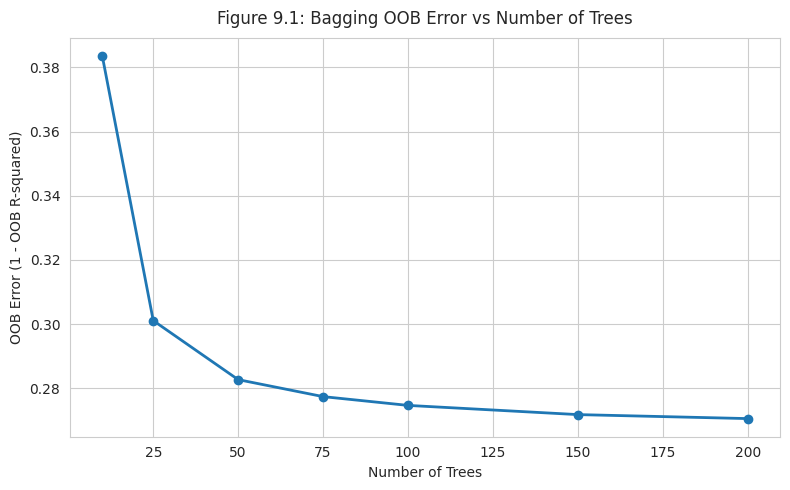

Saved: ../figures/ch09/bagging_oob.png


In [7]:
# Figure 9.1: OOB error vs number of trees for bagging

bag_tree_counts = [10, 25, 50, 75, 100, 150, 200]
bag_oob_errors = []

for n_trees in bag_tree_counts:
    try:
        model = BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            n_estimators=n_trees,
            oob_score=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    except TypeError:
        model = BaggingRegressor(
            base_estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            n_estimators=n_trees,
            oob_score=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    model.fit(X_train, y_train_reg)
    bag_oob_errors.append(1 - model.oob_score_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bag_tree_counts, bag_oob_errors, marker="o", linewidth=2)
ax.set_xlabel("Number of Trees")
ax.set_ylabel("OOB Error (1 - OOB R-squared)")
ax.set_title("Figure 9.1: Bagging OOB Error vs Number of Trees", pad=10)
plt.tight_layout()

fig_path_91 = os.path.join(FIGURES_DIR, "bagging_oob.png")
plt.savefig(fig_path_91, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_91}")

### Random Forest

Random forest is fit for both regression and classification. The grid search tests 50, 100, and 200 trees crossed with three values of `max_features`: `sqrt`, `log2`, and `0.5`.

In [8]:
# Random Forest regression tuning

rf_n_estimators_grid = [50, 100, 200]
rf_max_features_grid = ["sqrt", "log2", 0.5]

kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_reg_tuning = []

for n_trees in rf_n_estimators_grid:
    for max_features in rf_max_features_grid:
        model = RandomForestRegressor(
            n_estimators=n_trees,
            max_features=max_features,
            oob_score=True,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        scores = cross_val_score(
            model,
            X_train,
            y_train_reg,
            cv=kf5,
            scoring="r2",
            n_jobs=-1
        )
        rf_reg_tuning.append({
            "n_estimators": n_trees,
            "max_features": max_features,
            "CV R-squared Mean": scores.mean(),
            "CV R-squared Std": scores.std()
        })

rf_reg_tuning_df = pd.DataFrame(rf_reg_tuning).sort_values(
    "CV R-squared Mean",
    ascending=False
)

rf_reg_tuning_df

,n_estimators,max_features,CV R-squared Mean,CV R-squared Std
8,200,0.5,0.733974,0.003725
7,200,log2,0.733199,0.003804
6,200,sqrt,0.733199,0.003804
5,100,0.5,0.732569,0.003663
3,100,sqrt,0.731588,0.003818
4,100,log2,0.731588,0.003818
2,50,0.5,0.729823,0.003512
0,50,sqrt,0.728534,0.004051
1,50,log2,0.728534,0.004051


In [9]:
best_rf_reg_params = rf_reg_tuning_df.iloc[0].to_dict()

rf_reg = RandomForestRegressor(
    n_estimators=int(best_rf_reg_params["n_estimators"]),
    max_features=best_rf_reg_params["max_features"],
    oob_score=True,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train_reg)

rf_reg_pred = rf_reg.predict(X_test)
rf_reg_oob = rf_reg.oob_score_
rf_reg_test_rmse = rmse(y_test_reg, rf_reg_pred)
rf_reg_test_r2 = r2_score(y_test_reg, rf_reg_pred)

print("Random Forest Regressor")
print(f"Best params    : n_estimators={int(best_rf_reg_params['n_estimators'])}, max_features={best_rf_reg_params['max_features']}")
print(f"OOB score      : {rf_reg_oob:.5f}")
print(f"Test RMSE      : {rf_reg_test_rmse:.5f}")
print(f"Test R-squared : {rf_reg_test_r2:.5f}")

Random Forest Regressor
Best params    : n_estimators=200, max_features=0.5
OOB score      : 0.73218
Test RMSE      : 0.85589
Test R-squared : 0.73510


In [10]:
# Random Forest classification tuning

rf_cls_tuning = []

for n_trees in rf_n_estimators_grid:
    for max_features in rf_max_features_grid:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_features=max_features,
            oob_score=True,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )
        scores = cross_val_score(
            model,
            X_train,
            y_train_bin,
            cv=skf5,
            scoring="roc_auc",
            n_jobs=-1
        )
        rf_cls_tuning.append({
            "n_estimators": n_trees,
            "max_features": max_features,
            "CV AUC Mean": scores.mean(),
            "CV AUC Std": scores.std()
        })

rf_cls_tuning_df = pd.DataFrame(rf_cls_tuning).sort_values(
    "CV AUC Mean",
    ascending=False
)

rf_cls_tuning_df

,n_estimators,max_features,CV AUC Mean,CV AUC Std
7,200,log2,0.967414,0.004306
6,200,sqrt,0.967414,0.004306
8,200,0.5,0.965353,0.003712
3,100,sqrt,0.960176,0.003978
4,100,log2,0.960176,0.003978
5,100,0.5,0.956507,0.005190
0,50,sqrt,0.946645,0.003519
1,50,log2,0.946645,0.003519
2,50,0.5,0.941879,0.006138


In [11]:
best_rf_cls_params = rf_cls_tuning_df.iloc[0].to_dict()

rf_cls = RandomForestClassifier(
    n_estimators=int(best_rf_cls_params["n_estimators"]),
    max_features=best_rf_cls_params["max_features"],
    oob_score=True,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_cls.fit(X_train, y_train_bin)

rf_cls_pred = rf_cls.predict(X_test)
rf_cls_prob = rf_cls.predict_proba(X_test)[:, 1]

rf_cls_oob = rf_cls.oob_score_
rf_cls_accuracy = accuracy_score(y_test_bin, rf_cls_pred)
rf_cls_auc = roc_auc_score(y_test_bin, rf_cls_prob)

print("Random Forest Classifier")
print(f"Best params : n_estimators={int(best_rf_cls_params['n_estimators'])}, max_features={best_rf_cls_params['max_features']}")
print(f"OOB score   : {rf_cls_oob:.5f}")
print(f"Accuracy    : {rf_cls_accuracy:.5f}")
print(f"AUC-ROC     : {rf_cls_auc:.5f}")
print()
print(classification_report(y_test_bin, rf_cls_pred, target_names=["Not High", "High"]))

Random Forest Classifier
Best params : n_estimators=200, max_features=log2
OOB score   : 0.98626
Accuracy    : 0.98647
AUC-ROC     : 0.97424

              precision    recall  f1-score   support

    Not High       0.99      1.00      0.99     39397
        High       0.70      0.18      0.29       603

    accuracy                           0.99     40000
   macro avg       0.84      0.59      0.64     40000
weighted avg       0.98      0.99      0.98     40000



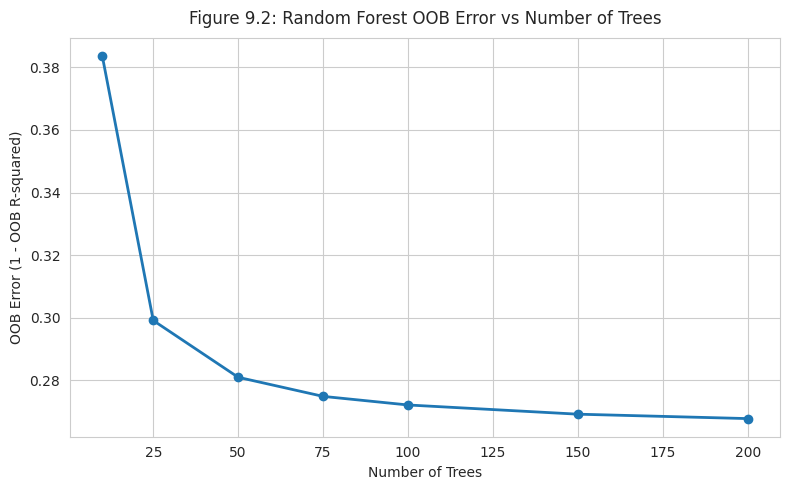

Saved: ../figures/ch09/rf_oob.png


In [12]:
# Figure 9.2: RF OOB error vs n_estimators
# Uses the best max_features from the regression tuning step.

rf_oob_tree_counts = [10, 25, 50, 75, 100, 150, 200]
rf_oob_errors = []

for n_trees in rf_oob_tree_counts:
    model = RandomForestRegressor(
        n_estimators=n_trees,
        max_features=best_rf_reg_params["max_features"],
        oob_score=True,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_train, y_train_reg)
    rf_oob_errors.append(1 - model.oob_score_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rf_oob_tree_counts, rf_oob_errors, marker="o", linewidth=2)
ax.set_xlabel("Number of Trees")
ax.set_ylabel("OOB Error (1 - OOB R-squared)")
ax.set_title("Figure 9.2: Random Forest OOB Error vs Number of Trees", pad=10)
plt.tight_layout()

fig_path_92 = os.path.join(FIGURES_DIR, "rf_oob.png")
plt.savefig(fig_path_92, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_92}")

### Gradient Boosting

Gradient boosting is fit for both regression and classification. For the regression model, the grid search tests learning rates of 0.01, 0.05, and 0.1 with tree depths of 3, 4, and 5. The same grid is also used for the classification model so that the AUC can be compared with the random forest classifier.

In [ ]:
# Gradient Boosting regression tuning with cache

gb_reg_tuning_cache_path = os.path.join(
    RESULTS_DIR,
    "gb_reg_tuning_cached_results.csv"
)

gb_learning_rates = [0.01, 0.05, 0.1]
gb_depths = [3, 4, 5]

if os.path.exists(gb_reg_tuning_cache_path):
    print("Loading cached Gradient Boosting regression tuning results.")
    
    gb_reg_tuning_df = pd.read_csv(gb_reg_tuning_cache_path).sort_values(
        "CV RMSE Mean"
    )

else:
    print("No cached regression tuning results found.")
    print("Running Gradient Boosting regression tuning. This may take a long time.")

    gb_reg_tuning = []

    for lr in gb_learning_rates:
        for depth in gb_depths:
            model = GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=lr,
                max_depth=depth,
                random_state=RANDOM_STATE
            )

            scores = cross_val_score(
                model,
                X_train,
                y_train_reg,
                cv=kf5,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

            gb_reg_tuning.append({
                "learning_rate": lr,
                "max_depth": depth,
                "CV RMSE Mean": -scores.mean(),
                "CV RMSE Std": scores.std()
            })

    gb_reg_tuning_df = pd.DataFrame(gb_reg_tuning).sort_values(
        "CV RMSE Mean"
    )

    gb_reg_tuning_df.to_csv(gb_reg_tuning_cache_path, index=False)

    print("Saved Gradient Boosting regression tuning results to cache.")
    print(f"Cache path: {gb_reg_tuning_cache_path}")

best_gb_reg_params = gb_reg_tuning_df.iloc[0].to_dict()

print("Best Gradient Boosting regression parameters:")
print(best_gb_reg_params)

gb_reg_tuning_df

,learning_rate,max_depth,CV RMSE Mean,CV RMSE Std
6,0.10,3,0.849227,0.003577
4,0.05,4,0.849247,0.003459
5,0.05,5,0.849311,0.003679
7,0.10,4,0.849924,0.003442
8,0.10,5,0.850736,0.003491
3,0.05,3,0.851081,0.003506
2,0.01,5,0.908169,0.001725
1,0.01,4,0.926305,0.001233
0,0.01,3,0.956866,0.000904


In [14]:
best_gb_reg_params = gb_reg_tuning_df.iloc[0].to_dict()

gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=float(best_gb_reg_params["learning_rate"]),
    max_depth=int(best_gb_reg_params["max_depth"]),
    random_state=RANDOM_STATE
)

gb_reg.fit(X_train, y_train_reg)

gb_reg_pred = gb_reg.predict(X_test)
gb_reg_test_rmse = rmse(y_test_reg, gb_reg_pred)
gb_reg_test_r2 = r2_score(y_test_reg, gb_reg_pred)

print("Gradient Boosting Regressor")
print(f"Best params    : learning_rate={best_gb_reg_params['learning_rate']}, max_depth={int(best_gb_reg_params['max_depth'])}, n_estimators=200")
print(f"Test RMSE      : {gb_reg_test_rmse:.5f}")
print(f"Test R-squared : {gb_reg_test_r2:.5f}")

Gradient Boosting Regressor
Best params    : learning_rate=0.1, max_depth=3, n_estimators=200
Test RMSE      : 0.84841
Test R-squared : 0.73971


In [ ]:
# Gradient Boosting classification tuning with cache

gb_cls_tuning_cache_path = os.path.join(
    RESULTS_DIR,
    "gb_cls_tuning_cached_results.csv"
)

if os.path.exists(gb_cls_tuning_cache_path):
    print("Loading cached Gradient Boosting classification tuning results.")
    
    gb_cls_tuning_df = pd.read_csv(gb_cls_tuning_cache_path).sort_values(
        "CV AUC Mean",
        ascending=False
    )

else:
    print("No cached classification tuning results found.")
    print("Running Gradient Boosting classification tuning. This may take a long time.")

    gb_cls_tuning = []

    for lr in gb_learning_rates:
        for depth in gb_depths:
            model = GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=lr,
                max_depth=depth,
                random_state=RANDOM_STATE
            )

            scores = cross_val_score(
                model,
                X_train,
                y_train_bin,
                cv=skf5,
                scoring="roc_auc",
                n_jobs=-1
            )

            gb_cls_tuning.append({
                "learning_rate": lr,
                "max_depth": depth,
                "CV AUC Mean": scores.mean(),
                "CV AUC Std": scores.std()
            })

    gb_cls_tuning_df = pd.DataFrame(gb_cls_tuning).sort_values(
        "CV AUC Mean",
        ascending=False
    )

    gb_cls_tuning_df.to_csv(gb_cls_tuning_cache_path, index=False)

    print("Saved Gradient Boosting classification tuning results to cache.")
    print(f"Cache path: {gb_cls_tuning_cache_path}")

best_gb_cls_params = gb_cls_tuning_df.iloc[0].to_dict()

print("Best Gradient Boosting classification parameters:")
print(best_gb_cls_params)

gb_cls_tuning_df

,learning_rate,max_depth,CV AUC Mean,CV AUC Std
6,0.10,3,0.977404,0.001085
4,0.05,4,0.976702,0.001395
3,0.05,3,0.976619,0.001175
7,0.10,4,0.976319,0.001225
5,0.05,5,0.976271,0.001218
8,0.10,5,0.975290,0.000638
2,0.01,5,0.974170,0.001421
1,0.01,4,0.972770,0.001389
0,0.01,3,0.969836,0.001407


In [16]:
best_gb_cls_params = gb_cls_tuning_df.iloc[0].to_dict()

gb_cls = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=float(best_gb_cls_params["learning_rate"]),
    max_depth=int(best_gb_cls_params["max_depth"]),
    random_state=RANDOM_STATE
)

gb_cls.fit(X_train, y_train_bin)

gb_cls_pred = gb_cls.predict(X_test)
gb_cls_prob = gb_cls.predict_proba(X_test)[:, 1]

gb_cls_accuracy = accuracy_score(y_test_bin, gb_cls_pred)
gb_cls_auc = roc_auc_score(y_test_bin, gb_cls_prob)

print("Gradient Boosting Classifier")
print(f"Best params : learning_rate={best_gb_cls_params['learning_rate']}, max_depth={int(best_gb_cls_params['max_depth'])}, n_estimators=200")
print(f"Accuracy    : {gb_cls_accuracy:.5f}")
print(f"AUC-ROC     : {gb_cls_auc:.5f}")
print()
print(classification_report(y_test_bin, gb_cls_pred, target_names=["Not High", "High"]))

Gradient Boosting Classifier
Best params : learning_rate=0.1, max_depth=3, n_estimators=200
Accuracy    : 0.98682
AUC-ROC     : 0.97959

              precision    recall  f1-score   support

    Not High       0.99      1.00      0.99     39397
        High       0.63      0.31      0.42       603

    accuracy                           0.99     40000
   macro avg       0.81      0.65      0.70     40000
weighted avg       0.98      0.99      0.98     40000



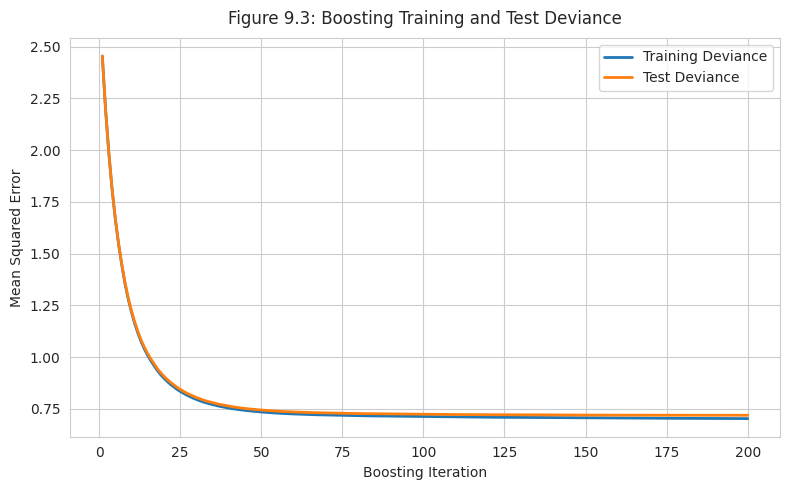

Saved: ../figures/ch09/boosting_deviance.png


In [17]:
# Figure 9.3: training and test deviance over boosting iterations
# For squared error regression, deviance is shown as mean squared error.

gb_train_deviance = []
gb_test_deviance = []

for y_train_stage_pred in gb_reg.staged_predict(X_train):
    gb_train_deviance.append(mean_squared_error(y_train_reg, y_train_stage_pred))

for y_test_stage_pred in gb_reg.staged_predict(X_test):
    gb_test_deviance.append(mean_squared_error(y_test_reg, y_test_stage_pred))

iterations = np.arange(1, len(gb_train_deviance) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, gb_train_deviance, linewidth=2, label="Training Deviance")
ax.plot(iterations, gb_test_deviance, linewidth=2, label="Test Deviance")
ax.set_xlabel("Boosting Iteration")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Figure 9.3: Boosting Training and Test Deviance", pad=10)
ax.legend()
plt.tight_layout()

fig_path_93 = os.path.join(FIGURES_DIR, "boosting_deviance.png")
plt.savefig(fig_path_93, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_93}")

## §9a. Bagging and Out-of-Bag Error

Out-of-bag error uses the bootstrap structure of bagging and random forests. Each tree is trained on a bootstrap sample, so some training rows are left out of that tree. Those left-out rows are called out-of-bag rows, and they can be used as a built-in evaluation set for that tree. Averaging this process across all trees gives an estimate of generalization performance without touching the validation set. This is valid here because every tree leaves out a different subset of rows, so the OOB score is based on predictions from trees that did not train on those specific rows.

In [18]:
oob_summary = pd.DataFrame({
    "Model": ["Bagging Regressor", "Random Forest Regressor"],
    "OOB Score": [bagging_oob, rf_reg_oob],
    "Test RMSE": [bagging_test_rmse, rf_reg_test_rmse],
    "Test R-squared": [bagging_test_r2, rf_reg_test_r2]
})

oob_summary.round(5)

,Model,OOB Score,Test RMSE,Test R-squared
0,Bagging Regressor,0.72537,0.86110,0.73187
1,Random Forest Regressor,0.73218,0.85589,0.73510


## §9b. Variable Importance

Variable importance is extracted from the random forest regressor and the gradient boosting regressor. The random forest importance reflects average impurity reduction across many decorrelated trees. The boosting importance reflects which variables were most useful while sequentially correcting earlier prediction errors.

In [19]:
# Feature importance tables

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_reg.feature_importances_
})

gb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Boosting Importance": gb_reg.feature_importances_
})

importance_df = rf_importance.merge(gb_importance, on="Feature")
importance_df["Domain"] = importance_df["Feature"].apply(feature_domain)

importance_df["RF Rank"] = importance_df["RF Importance"].rank(ascending=False, method="min").astype(int)
importance_df["Boosting Rank"] = importance_df["Boosting Importance"].rank(ascending=False, method="min").astype(int)

importance_df.sort_values("RF Importance", ascending=False).head(15)

,Feature,RF Importance,Boosting Importance,Domain,RF Rank,Boosting Rank
4,stress_level,0.406266,0.664613,Psychological,1,1
5,anxiety_score,0.164902,0.117802,Psychological,2,2
6,depression_score,0.113088,0.069240,Psychological,3,3
7,sleep_hours,0.066986,0.061402,Lifestyle,4,4
9,social_support,0.058342,0.053825,Lifestyle,5,5
2,exam_pressure,0.044225,0.031884,Academic,6,6
1,study_hours_per_day,0.021051,0.000313,Academic,7,7
12,financial_stress,0.018849,0.000111,External Stressor,8,12
3,academic_performance,0.017989,0.000107,Academic,9,13
13,family_expectation,0.017976,0.000197,External Stressor,10,8


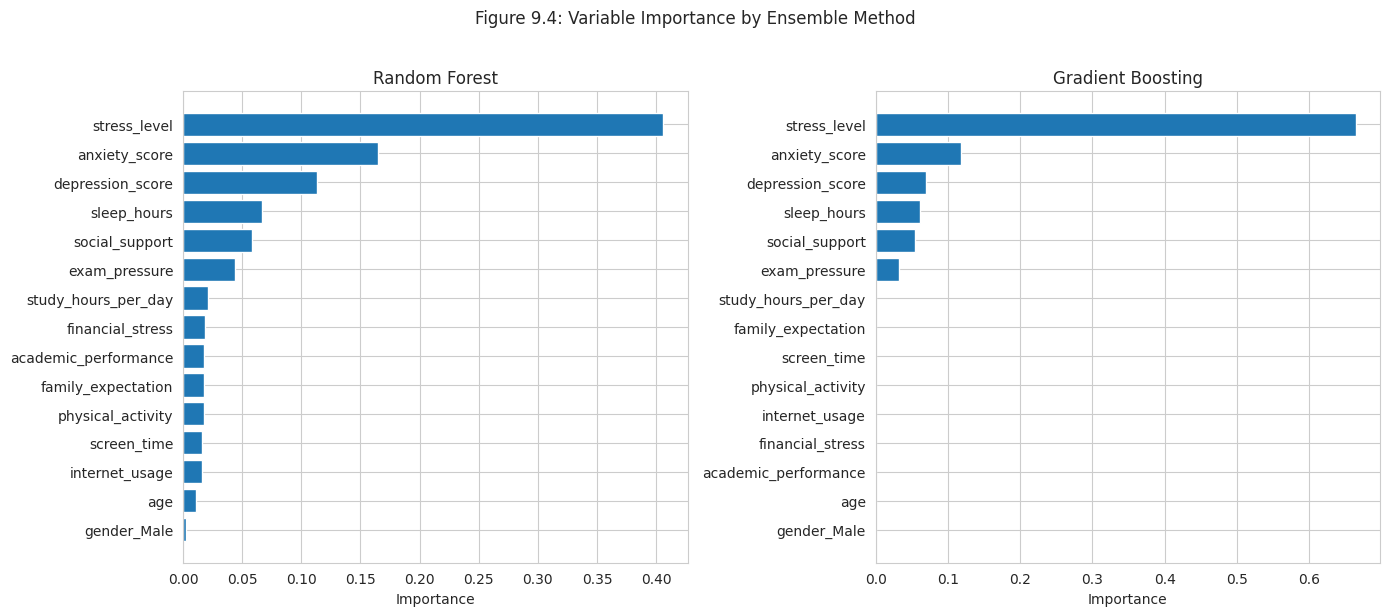

Saved: ../figures/ch09/variable_importance.png


In [20]:
# Figure 9.4: side-by-side bar charts for top 15 features

top15_rf = importance_df.sort_values("RF Importance", ascending=False).head(15)
top15_gb = importance_df.sort_values("Boosting Importance", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top15_rf["Feature"][::-1], top15_rf["RF Importance"][::-1])
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Importance")

axes[1].barh(top15_gb["Feature"][::-1], top15_gb["Boosting Importance"][::-1])
axes[1].set_title("Gradient Boosting")
axes[1].set_xlabel("Importance")

fig.suptitle("Figure 9.4: Variable Importance by Ensemble Method", y=1.02)
plt.tight_layout()

fig_path_94 = os.path.join(FIGURES_DIR, "variable_importance.png")
plt.savefig(fig_path_94, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_94}")

In [21]:
# Compare top five feature rankings

top5_compare = pd.DataFrame({
    "RF Top 5 Features": importance_df.sort_values("RF Importance", ascending=False)["Feature"].head(5).values,
    "RF Importance": importance_df.sort_values("RF Importance", ascending=False)["RF Importance"].head(5).values,
    "Boosting Top 5 Features": importance_df.sort_values("Boosting Importance", ascending=False)["Feature"].head(5).values,
    "Boosting Importance": importance_df.sort_values("Boosting Importance", ascending=False)["Boosting Importance"].head(5).values,
})

top5_compare.round(5)

,RF Top 5 Features,RF Importance,Boosting Top 5 Features,Boosting Importance
0,stress_level,0.40627,stress_level,0.66461
1,anxiety_score,0.16490,anxiety_score,0.11780
2,depression_score,0.11309,depression_score,0.06924
3,sleep_hours,0.06699,sleep_hours,0.06140
4,social_support,0.05834,social_support,0.05383


In [22]:
rf_top5_set = set(top5_compare["RF Top 5 Features"])
gb_top5_set = set(top5_compare["Boosting Top 5 Features"])

shared_top5 = sorted(rf_top5_set.intersection(gb_top5_set))
rf_only_top5 = sorted(rf_top5_set.difference(gb_top5_set))
gb_only_top5 = sorted(gb_top5_set.difference(rf_top5_set))

print("Top 5 agreement between Random Forest and Boosting:")
print(f"Shared top 5 features: {shared_top5}")
print(f"Only in RF top 5     : {rf_only_top5}")
print(f"Only in Boost top 5  : {gb_only_top5}")

Top 5 agreement between Random Forest and Boosting:
Shared top 5 features: ['anxiety_score', 'depression_score', 'sleep_hours', 'social_support', 'stress_level']
Only in RF top 5     : []
Only in Boost top 5  : []


In [23]:
# Domain-level importance totals

domain_importance = (
    importance_df
    .groupby("Domain", as_index=False)
    .agg({
        "RF Importance": "sum",
        "Boosting Importance": "sum"
    })
)

domain_importance["Average Importance"] = (
    domain_importance["RF Importance"] + domain_importance["Boosting Importance"]
) / 2

domain_importance = domain_importance.sort_values("Average Importance", ascending=False)

domain_importance.round(5)

,Domain,RF Importance,Boosting Importance,Average Importance
4,Psychological,0.68426,0.85166,0.76796
3,Lifestyle,0.17524,0.11567,0.14545
0,Academic,0.08934,0.03231,0.06083
2,External Stressor,0.03682,0.00031,0.01857
1,Demographic,0.01434,0.00006,0.00720


## §6. Diagnostics and Tuning

The main tuning choices are the number of trees, the number of candidate features allowed at each random forest split, the boosting learning rate, and boosting tree depth. The OOB curves are used to check whether adding more trees still changes the model meaningfully. A curve that flattens suggests the ensemble has converged and that additional trees would add computation without much improvement.

In [24]:
# Final hyperparameter summary

hyperparameter_summary = pd.DataFrame([
    {
        "Model": "Bagging Regressor",
        "Best Params": "n_estimators=100, base tree=DecisionTreeRegressor",
        "Selection Method": "Required model specification with OOB check"
    },
    {
        "Model": "Random Forest Regressor",
        "Best Params": f"n_estimators={int(best_rf_reg_params['n_estimators'])}, max_features={best_rf_reg_params['max_features']}",
        "Selection Method": "5-fold CV using R-squared"
    },
    {
        "Model": "Random Forest Classifier",
        "Best Params": f"n_estimators={int(best_rf_cls_params['n_estimators'])}, max_features={best_rf_cls_params['max_features']}",
        "Selection Method": "5-fold stratified CV using AUC-ROC"
    },
    {
        "Model": "Gradient Boosting Regressor",
        "Best Params": f"n_estimators=200, learning_rate={best_gb_reg_params['learning_rate']}, max_depth={int(best_gb_reg_params['max_depth'])}",
        "Selection Method": "5-fold CV using RMSE"
    },
    {
        "Model": "Gradient Boosting Classifier",
        "Best Params": f"n_estimators=200, learning_rate={best_gb_cls_params['learning_rate']}, max_depth={int(best_gb_cls_params['max_depth'])}",
        "Selection Method": "5-fold stratified CV using AUC-ROC"
    }
])

hyperparameter_summary

,Model,Best Params,Selection Method
0,Bagging Regressor,"n_estimators=100, base tree=DecisionTreeRegressor",Required model specification with OOB check
1,Random Forest Regressor,"n_estimators=200, max_features=0.5",5-fold CV using R-squared
2,Random Forest Classifier,"n_estimators=200, max_features=log2",5-fold stratified CV using AUC-ROC
3,Gradient Boosting Regressor,"n_estimators=200, learning_rate=0.1, max_depth=3",5-fold CV using RMSE
4,Gradient Boosting Classifier,"n_estimators=200, learning_rate=0.1, max_depth=3",5-fold stratified CV using AUC-ROC


In [25]:
# OOB convergence summary from the final curves

oob_convergence_summary = pd.DataFrame({
    "Curve": ["Bagging", "Random Forest"],
    "First OOB Error": [bag_oob_errors[0], rf_oob_errors[0]],
    "Final OOB Error": [bag_oob_errors[-1], rf_oob_errors[-1]],
    "Change": [bag_oob_errors[0] - bag_oob_errors[-1], rf_oob_errors[0] - rf_oob_errors[-1]]
})

oob_convergence_summary.round(5)

,Curve,First OOB Error,Final OOB Error,Change
0,Bagging,0.38357,0.27052,0.11306
1,Random Forest,0.38362,0.26782,0.11580


## §7. Findings

The findings table combines the regression and classification ensemble results. RMSE and R-squared apply to regression models, while accuracy and AUC apply to classification models. OOB score is available only for bagging and random forest models that use bootstrap sampling.

In [26]:
model_results = pd.DataFrame([
    {
        "Model": "Bagging Regressor",
        "Best Params": "n_estimators=100",
        "Test RMSE": bagging_test_rmse,
        "Test R-squared": bagging_test_r2,
        "OOB Score": bagging_oob,
        "Accuracy": np.nan,
        "AUC": np.nan
    },
    {
        "Model": "Random Forest Regressor",
        "Best Params": f"n_estimators={int(best_rf_reg_params['n_estimators'])}, max_features={best_rf_reg_params['max_features']}",
        "Test RMSE": rf_reg_test_rmse,
        "Test R-squared": rf_reg_test_r2,
        "OOB Score": rf_reg_oob,
        "Accuracy": np.nan,
        "AUC": np.nan
    },
    {
        "Model": "Random Forest Classifier",
        "Best Params": f"n_estimators={int(best_rf_cls_params['n_estimators'])}, max_features={best_rf_cls_params['max_features']}",
        "Test RMSE": np.nan,
        "Test R-squared": np.nan,
        "OOB Score": rf_cls_oob,
        "Accuracy": rf_cls_accuracy,
        "AUC": rf_cls_auc
    },
    {
        "Model": "Gradient Boosting Regressor",
        "Best Params": f"n_estimators=200, learning_rate={best_gb_reg_params['learning_rate']}, max_depth={int(best_gb_reg_params['max_depth'])}",
        "Test RMSE": gb_reg_test_rmse,
        "Test R-squared": gb_reg_test_r2,
        "OOB Score": np.nan,
        "Accuracy": np.nan,
        "AUC": np.nan
    },
    {
        "Model": "Gradient Boosting Classifier",
        "Best Params": f"n_estimators=200, learning_rate={best_gb_cls_params['learning_rate']}, max_depth={int(best_gb_cls_params['max_depth'])}",
        "Test RMSE": np.nan,
        "Test R-squared": np.nan,
        "OOB Score": np.nan,
        "Accuracy": gb_cls_accuracy,
        "AUC": gb_cls_auc
    }
])

model_results.round(5)

,Model,Best Params,Test RMSE,Test R-squared,OOB Score,Accuracy,AUC
0,Bagging Regressor,n_estimators=100,0.86110,0.73187,0.72537,NaN,NaN
1,Random Forest Regressor,"n_estimators=200, max_features=0.5",0.85589,0.73510,0.73218,NaN,NaN
2,Random Forest Classifier,"n_estimators=200, max_features=log2",NaN,NaN,0.98626,0.98648,0.97424
3,Gradient Boosting Regressor,"n_estimators=200, learning_rate=0.1, max_depth=3",0.84841,0.73971,NaN,NaN,NaN
4,Gradient Boosting Classifier,"n_estimators=200, learning_rate=0.1, max_depth=3",NaN,NaN,NaN,0.98682,0.97959


In [27]:
print("Top 5 features by ensemble method")
display(top5_compare.round(5))

print("Domain importance summary")
display(domain_importance.round(5))

Top 5 features by ensemble method


,RF Top 5 Features,RF Importance,Boosting Top 5 Features,Boosting Importance
0,stress_level,0.40627,stress_level,0.66461
1,anxiety_score,0.16490,anxiety_score,0.11780
2,depression_score,0.11309,depression_score,0.06924
3,sleep_hours,0.06699,sleep_hours,0.06140
4,social_support,0.05834,social_support,0.05383


Domain importance summary


,Domain,RF Importance,Boosting Importance,Average Importance
4,Psychological,0.68426,0.85166,0.76796
3,Lifestyle,0.17524,0.11567,0.14545
0,Academic,0.08934,0.03231,0.06083
2,External Stressor,0.03682,0.00031,0.01857
1,Demographic,0.01434,0.00006,0.00720


In [28]:
# Save key results

main_csv_path = os.path.join(RESULTS_DIR, "ensembles_results.csv")
importance_csv_path = os.path.join(RESULTS_DIR, "feature_importance.csv")
domain_csv_path = os.path.join(RESULTS_DIR, "domain_importance.csv")
tuning_csv_path = os.path.join(RESULTS_DIR, "tuning_results.csv")

model_results.to_csv(main_csv_path, index=False)
importance_df.to_csv(importance_csv_path, index=False)
domain_importance.to_csv(domain_csv_path, index=False)

with open(tuning_csv_path, "w") as f:
    f.write("Random Forest Regression Tuning\n")
    rf_reg_tuning_df.to_csv(f, index=False)
    f.write("\nRandom Forest Classification Tuning\n")
    rf_cls_tuning_df.to_csv(f, index=False)
    f.write("\nGradient Boosting Regression Tuning\n")
    gb_reg_tuning_df.to_csv(f, index=False)
    f.write("\nGradient Boosting Classification Tuning\n")
    gb_cls_tuning_df.to_csv(f, index=False)

print("Saved results:")
print(f"  {main_csv_path}")
print(f"  {importance_csv_path}")
print(f"  {domain_csv_path}")
print(f"  {tuning_csv_path}")

Saved results:
  ../results/ch09/ensembles_results.csv
  ../results/ch09/feature_importance.csv
  ../results/ch09/domain_importance.csv
  ../results/ch09/tuning_results.csv


## §8. Real-World Decision

The domain importance table should guide the practical recommendation. If the psychological domain has the largest combined importance across random forest and boosting, then the first investment should be early screening and support around stress, anxiety, and depression indicators. This would match the logistic regression findings in Chapter 5, where stress level, anxiety score, and depression score were among the strongest signals for High-risk classification. If the lifestyle domain is close behind, then sleep, social support, screen time, and physical activity should be treated as secondary intervention targets rather than ignored. The defensible decision is not to fund a single narrow program, but to build a screening workflow that prioritizes the strongest domain first and then uses the next strongest domain to refine outreach.

## §9. Caveats and Limitations

Tree ensembles are more accurate and stable than a single tree, but they are harder to explain because the final prediction comes from many trees rather than one clear rule. They are also computationally expensive, especially when cross-validation is used across many hyperparameter settings. Feature importance can be biased toward variables with more possible split points or stronger correlation with other predictors, so the domain rankings should be interpreted as predictive importance rather than causal evidence.

In [29]:
print("Chapter 9 complete.")
print()
print("Figures")
for path in [fig_path_91, fig_path_92, fig_path_93, fig_path_94]:
    print(f"  {path}")
print()
print("Results")
for path in [main_csv_path, importance_csv_path, domain_csv_path, tuning_csv_path]:
    print(f"  {path}")

Chapter 9 complete.

Figures
  ../figures/ch09/bagging_oob.png
  ../figures/ch09/rf_oob.png
  ../figures/ch09/boosting_deviance.png
  ../figures/ch09/variable_importance.png

Results
  ../results/ch09/ensembles_results.csv
  ../results/ch09/feature_importance.csv
  ../results/ch09/domain_importance.csv
  ../results/ch09/tuning_results.csv
